In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')))

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data.csv


In [3]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [5]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-6-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1085 non-null   datetime64[ns]
 1   Price   1085 non-null   float64       
 2   Open    1085 non-null   float64       
 3   High    1085 non-null   float64       
 4   Low     1085 non-null   float64       
 5   Vol.    1085 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 51.0 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

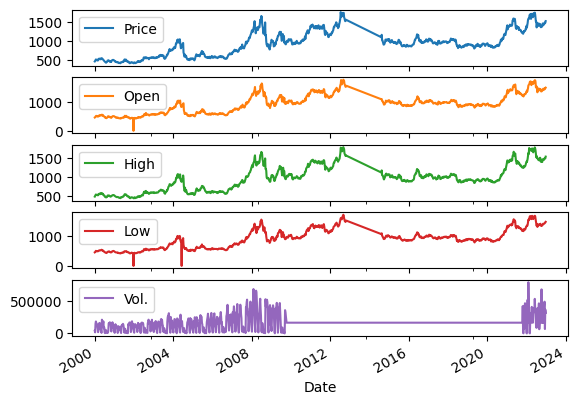

In [8]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [9]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,1524.00,1495.75,1537.50,1485.00,321320.0
1,1479.00,1470.00,1489.00,1460.00,374100.0
2,1480.00,1482.12,1487.62,1457.75,69330.0
3,1483.75,1440.50,1492.75,1435.25,496710.0
4,1438.50,1428.25,1478.50,1424.00,420750.0
...,...,...,...,...,...
1080,505.50,519.50,519.50,495.00,165260.0
1081,523.50,510.25,529.50,508.00,187680.0
1082,505.25,489.00,507.50,486.50,151590.0
1083,485.50,468.00,490.00,464.00,17610.0


In [10]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,1085.000000,1085.000000,1085.000000,1085.000000,1085.000000
mean,925.625548,923.974111,948.017687,901.644885,168395.089606
std,322.870920,323.264397,331.580002,314.104187,103435.556606
min,422.750000,0.000000,426.000000,0.000000,840.000000
25%,612.000000,612.750000,629.000000,598.500000,133680.000000
50%,919.120000,920.000000,941.380000,901.120000,168395.089606
75%,1100.620000,1094.000000,1140.000000,1053.000000,168395.089606
max,1758.380000,1772.630000,1788.880000,1725.630000,800250.000000


In [11]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.82451727, 0.84380271, 0.81555236, 0.86055528, 0.40089566],
       [0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935],
       [0.79157401, 0.83611357, 0.77895339, 0.84476394, 0.08567569],
       ...,
       [0.0617686 , 0.27586129, 0.05979984, 0.28192602, 0.18857658],
       [0.04698157, 0.26401449, 0.04695938, 0.2688873 , 0.02097797],
       [0.03649963, 0.26006555, 0.03448579, 0.26410644, 0.05190078]])

In [12]:
from pandas.core.tools.datetimes import YearMonthDayDict
# Extracting the target variable 
X=data_scaled #attributes include all the columns including the target
y=data_scaled[:,0] #target only the first column = price

In [13]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(X, y, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.82451727, 0.84380271, 0.81555236, 0.86055528, 0.40089566],
         [0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935]]]),
 array([0.79157401]))

In [14]:
# Splitting the dataset in 80% train and 0.2% test dataset. 
# Shuffle=False because its a time series data
# x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.2, random_state=42, shuffle=False)

In [15]:
# Addition
# Select the rows for the training set (2000-2019)
x_train = X[data['Date'].dt.year.between(2000, 2019)]
y_train = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
x_test = X[data['Date'].dt.year.between(2020, 2022)]
y_test = y[data['Date'].dt.year.between(2020, 2022)]

In [16]:
x_train.shape, x_test.shape

((929, 5), (156, 5))

In [17]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=16
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [18]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.37959615, 0.52436211, 0.38383423, 0.53705024, 0.20959844],
         [0.37969348, 0.52408004, 0.37815508, 0.5375544 , 0.20959844],
         [0.37837575, 0.51498621, 0.37045081, 0.52901259, 0.20959844],
         [0.36265283, 0.49988999, 0.36017845, 0.51321546, 0.20959844]],
 
        [[0.37969348, 0.52408004, 0.37815508, 0.5375544 , 0.20959844],
         [0.37837575, 0.51498621, 0.37045081, 0.52901259, 0.20959844],
         [0.36265283, 0.49988999, 0.36017845, 0.51321546, 0.20959844],
         [0.34917604, 0.49453073, 0.34347852, 0.50278449, 0.20959844]],
 
        [[0.37837575, 0.51498621, 0.37045081, 0.52901259, 0.20959844],
         [0.36265283, 0.49988999, 0.36017845, 0.51321546, 0.20959844],
         [0.34917604, 0.49453073, 0.34347852, 0.50278449, 0.20959844],
         [0.33981716, 0.5053226 , 0.34971531, 0.50771023, 0.20959844]],
 
        [[0.36265283, 0.49988999, 0.36017845, 0.51321546, 0.20959844],
         [0.34917604, 0.49453073, 0.34347852, 0.50278449, 0.20959844

In [19]:
# LSTM model architecture
from tensorflow.keras import regularizers

# LSTM model architecture
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) # LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.LSTM(128, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.Dense(1))

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [21]:
# Defining the model
# early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Nadam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])

Epoch 1/100


<ipython-input-21-23af3bb68b41>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])


58/58 [==============================] - 8s 44ms/step - loss: 40.3619 - mean_absolute_error: 0.1926 - val_loss: 14.8196 - val_mean_absolute_error: 0.5476
Epoch 2/100
58/58 [==============================] - 1s 18ms/step - loss: 4.3095 - mean_absolute_error: 0.2153 - val_loss: 0.4653 - val_mean_absolute_error: 0.5204
Epoch 3/100
58/58 [==============================] - 1s 16ms/step - loss: 0.1968 - mean_absolute_error: 0.2447 - val_loss: 0.3775 - val_mean_absolute_error: 0.4699
Epoch 4/100
58/58 [==============================] - 1s 23ms/step - loss: 0.1893 - mean_absolute_error: 0.2388 - val_loss: 0.3545 - val_mean_absolute_error: 0.4447
Epoch 5/100
58/58 [==============================] - 1s 17ms/step - loss: 0.1864 - mean_absolute_error: 0.2329 - val_loss: 0.3368 - val_mean_absolute_error: 0.4233
Epoch 6/100
58/58 [==============================] - 1s 17ms/step - loss: 0.1841 - mean_absolute_error: 0.2287 - val_loss: 0.3285 - val_mean_absolute_error: 0.4134
Epoch 7/100
58/58 [=======

In [22]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-22-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[0.4866825342178345, 0.5597525835037231]

In [23]:
predictions=model.predict_generator(test_generator)

<ipython-input-23-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [24]:
# Test data had 156 datapoints and 4 win_length hence the prediction shape is 152
predictions.shape[0]

152

In [25]:
predictions

array([[0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.08007093],
       [0.080

In [26]:
x_test, y_test

(array([[8.24517269e-01, 8.43802711e-01, 8.15552360e-01, 8.60555275e-01,
         4.00895661e-01],
        [7.90825303e-01, 8.29276273e-01, 7.79965954e-01, 8.46067813e-01,
         4.66919353e-01],
        [7.91574014e-01, 8.36113571e-01, 7.78953393e-01, 8.44763941e-01,
         8.56756858e-02],
        [7.94381678e-01, 8.12634334e-01, 7.82717481e-01, 8.31725225e-01,
         6.20294968e-01],
        [7.60502534e-01, 8.05723699e-01, 7.72261681e-01, 8.25205867e-01,
         5.25274890e-01],
        [7.57133338e-01, 8.04668769e-01, 7.49794553e-01, 8.21294252e-01,
         2.09598441e-01],
        [7.52828253e-01, 8.23634938e-01, 7.62172752e-01, 8.15209518e-01,
         3.55412116e-01],
        [7.70520279e-01, 8.19686003e-01, 7.65012327e-01, 8.23467371e-01,
         2.09598441e-01],
        [7.78284405e-01, 7.98248930e-01, 7.62723057e-01, 8.09994031e-01,
         5.30641348e-01],
        [7.22505484e-01, 7.84495354e-01, 7.13107537e-01, 7.91594954e-01,
         2.09598441e-01],
        [7

In [27]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.8057237 , 0.80466877, 0.82363494, 0.819686  , 0.79824893,
       0.78449535, 0.77885402, 0.77117052, 0.76947812, 0.80389026,
       0.81573707, 0.7947231 , 0.80459543, 0.82335287, 0.78865866,
       0.8133395 , 0.78894073, 0.83336624, 0.75311825, 0.83393037,
       0.86777839, 0.84281548, 0.85226471, 0.95620631, 0.98807986,
       0.96410418, 0.98032302, 0.96241178, 0.93505131, 0.9160118 ,
       0.95006854, 0.95183428, 0.95268048, 0.95394978, 0.89358749,
       0.96128352, 0.94379538, 0.96354005, 0.95705252, 0.92658931,
       0.90769083, 0.89527989, 0.88625376, 0.8324467 , 0.80078753,
       0.76722159, 0.78640213, 0.75607995, 0.75452858, 0.72745017,
       0.7170137 , 0.7174368 , 0.71123133, 0.7136966 , 0.70079486,
       0.67131889, 0.69741006, 0.68753773, 0.68739669, 0.69938453,
       0.7017821 , 0.72406537, 0.72378331, 0.728082  , 0.72879281,
       0.74415981, 0.72674501, 0.76468299, 0.75565685, 0.76164795,
       0.75749028, 0.78203009, 0.74740922, 0.73986111, 0.71581

In [28]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-28-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.080071,0.805724,0.772262,0.825206,0.525275
1,0.080071,0.804669,0.749795,0.821294,0.209598
2,0.080071,0.823635,0.762173,0.815210,0.355412
3,0.080071,0.819686,0.765012,0.823467,0.209598
4,0.080071,0.798249,0.762723,0.809994,0.530641
...,...,...,...,...,...
147,0.080071,0.491428,0.338900,0.503515,0.209598
148,0.080071,0.507370,0.349906,0.505543,0.209598
149,0.080071,0.524859,0.370994,0.521908,0.209598
150,0.080071,0.535013,0.383467,0.533208,0.209598


In [29]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[5.29695133e+02, 1.42825000e+03, 1.47850000e+03, 1.42400000e+03,
        4.20750000e+05],
       [5.29695133e+02, 1.42638000e+03, 1.44788000e+03, 1.41725000e+03,
        1.68395090e+05],
       [5.29695133e+02, 1.46000000e+03, 1.46475000e+03, 1.40675000e+03,
        2.84960000e+05],
       [5.29695133e+02, 1.45300000e+03, 1.46862000e+03, 1.42100000e+03,
        1.68395090e+05],
       [5.29695133e+02, 1.41500000e+03, 1.46550000e+03, 1.39775000e+03,
        4.25040000e+05],
       [5.29695133e+02, 1.39062000e+03, 1.39788000e+03, 1.36600000e+03,
        1.68395090e+05],
       [5.29695133e+02, 1.38062000e+03, 1.39862000e+03, 1.35725000e+03,
        1.68395090e+05],
       [5.29695133e+02, 1.36700000e+03, 1.41400000e+03, 1.36525000e+03,
        6.88950000e+05],
       [5.29695133e+02, 1.36400000e+03, 1.39500000e+03, 1.35000000e+03,
        4.61470000e+05],
       [5.29695133e+02, 1.42500000e+03, 1.43712000e+03, 1.36325000e+03,
        1.68395090e+05],
       [5.29695133e+02, 1.4460

In [30]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(       Price    Open   High     Low      Vol.
 933   578.75  571.75  581.5  567.50  102630.0
 934   571.75  563.00  577.5  560.25  175870.0
 935   563.25  563.25  581.0  561.00   42290.0
 936   563.25  566.00  585.0  562.50   31560.0
 937   568.50  553.50  569.0  545.00  151300.0
 ...      ...     ...    ...     ...       ...
 1080  505.50  519.50  519.5  495.00  165260.0
 1081  523.50  510.25  529.5  508.00  187680.0
 1082  505.25  489.00  507.5  486.50  151590.0
 1083  485.50  468.00  490.0  464.00   17610.0
 1084  471.50  461.00  473.0  455.75   42330.0
 
 [152 rows x 5 columns],
 Price    152
 Open     152
 High     152
 Low      152
 Vol.     152
 dtype: int64)

In [31]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-31-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
933,578.75,571.75,581.5,567.50,102630.0,529.695133
934,571.75,563.00,577.5,560.25,175870.0,529.695133
935,563.25,563.25,581.0,561.00,42290.0,529.695133
936,563.25,566.00,585.0,562.50,31560.0,529.695133
937,568.50,553.50,569.0,545.00,151300.0,529.695133
...,...,...,...,...,...,...
1080,505.50,519.50,519.5,495.00,165260.0,529.695133
1081,523.50,510.25,529.5,508.00,187680.0,529.695133
1082,505.25,489.00,507.5,486.50,151590.0,529.695133
1083,485.50,468.00,490.0,464.00,17610.0,529.695133


<Axes: >

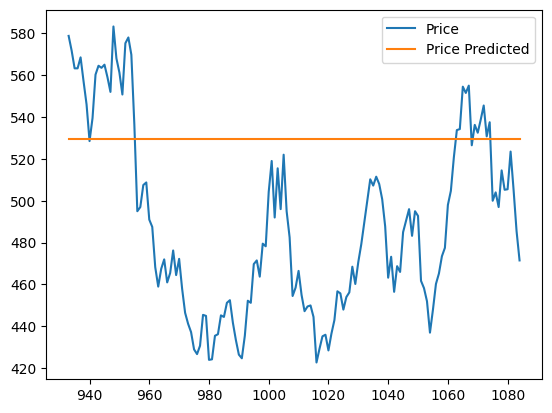

In [32]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [33]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
no display found. Using non-interactive Agg backend


In [34]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : -41.1326
       Root Mean Squared Error (RMSE) : 59.8233
            Mean Absolute Error (MAE) : 52.2551
          Mean Percentage Error (MPE) : -9.2531
Mean Absolute Percentage Error (MAPE) : 11.2262
